# 13b · blacklist #1

One of three arms sharing 13a's data. **Run 13a first** — all three
read `cleaned_data_codes.txt` and `outputs_codes/run_config.joblib`,
and none of them re-cleans anything.

| arm | blacklist | bundle |
|---|---|---|
| `13b_noblack` | none | `nn_codes_noblack` |
| `13b_bl1` | `blacklist_1.txt` | `nn_codes_bl1` |
| `13b_bl2` | `blacklist_2.txt` | `nn_codes_bl2` |

**This notebook is `bl1`.** Every path below derives from that one
constant, so the bundle cannot be written under another arm's name.
The three can run at once on separate clusters: they read the same
files and write different ones.

Score it with `06_predict_bl1.ipynb`, which checks the bundle's
provenance stamp before it trusts it.

Comparators: 12b vendor-only **0.8036**, 12c no markers **0.7815**.

In [0]:
import os, pathlib, sys

# Point at 11a's isolated outputs BEFORE anything reads them. Without
# this the notebook silently loads the shared config and trains a
# duplicate of 10b on the wrong data.
ROOT = pathlib.Path.cwd()
if not (ROOT / "nn_classifier").is_dir():
    ROOT = ROOT.parent
ARM_OUTPUT_DIR = str(ROOT / "outputs_codes")
os.environ["NN_CLASSIFIER_OUTPUT_DIR"] = ARM_OUTPUT_DIR

if not (pathlib.Path(ARM_OUTPUT_DIR) / "run_config.joblib").exists():
    raise FileNotFoundError(
        f"No config in {ARM_OUTPUT_DIR}. Run 11a first -- this arm "
        "trains on the vendor-marked data it writes."
    )
print(f"outputs -> {ARM_OUTPUT_DIR}")


# =====================================================================
# ARM REGISTRY -- identical in all six notebooks. Do not edit per file.
#
# Every path derives from ARM, so a bundle, a blacklist and a
# predictions file cannot end up belonging to different arms.
# =====================================================================
ARMS = {
    "noblack": {"label": "no blacklist", "blacklist": None},
    "bl1":     {"label": "blacklist #1", "blacklist": "blacklist_1.txt"},
    "bl2":     {"label": "blacklist #2", "blacklist": "blacklist_2.txt"},
}

ARM = "bl1"      # <- the only line that differs between arms
assert ARM in ARMS, f"ARM={ARM!r}; expected one of {list(ARMS)}"

BLACKLIST_FILE = ARMS[ARM]["blacklist"]
BLACKLIST_SCOPE = "train"          # "train" | "all" -- see below
BUNDLE_NAME = f"nn_codes_{ARM}"
ARM_LABEL = ARMS[ARM]["label"]

print(f"arm       : {ARM}  ({ARM_LABEL})")
print(f"reads     : {ARM_OUTPUT_DIR}")
print(f"blacklist : {BLACKLIST_FILE or 'none'}")
print(f"writes    : {ARM_OUTPUT_DIR}/{BUNDLE_NAME}")

outputs -> /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes
arm       : bl1  (blacklist #1)
reads     : /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes
blacklist : blacklist_1.txt
writes    : /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1


In [0]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "nn_classifier").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

import nn_classifier as nnc
from nn_classifier import paths
print(paths.describe())


[paths] scratch: /local_disk0/tmp (cluster SSD): PermissionError -- using /tmp/nn_classifier
environment: Databricks
  data dir:   /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/data
  output dir: /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes
  scratch:    /tmp/nn_classifier  (118 GB free)
  device:     cpu


In [0]:
# The plain setup, unchanged. The blacklist cannot be applied here --
# BLACKLIST_FILE is defined in the settings cell below, and this one
# runs first. The cell after the settings rebuilds the split and does
# apply it, so the work here is superseded rather than wasted.
from nn_classifier import calibration, data, evaluation, hierarchy, plotting, vectorization
from nn_classifier.config import load_config

# The decisions made in notebook 02, not a fresh default. Three models
# tuned against three quietly different feature spaces are not
# comparable, and the difference would look like a modelling result.
cfg = load_config()
cfg.validate()          # unpickling skips __post_init__, so check explicitly
levels = list(cfg.data.level_columns)

df = data.load_data(cfg.data)
train_df, val_df = data.prepare(df, cfg.data, cfg.filters, cfg.split)

# Rare-token pruning, AFTER the split and counted on the training rows
# only. Counting across everything would let the validation set vote on
# which of its own tokens survive, and the resulting score is optimistic
# in a way nothing later in the pipeline will catch. A no-op while
# FilterConfig.min_token_count is 1.
train_df, (val_df,), keep_vocab = nnc.cleaning.drop_one_off_tokens(
    train_df, [val_df],
    text_col=cfg.data.text_col,
    min_count=cfg.filters.min_token_count,
    min_classes=cfg.filters.min_token_classes,
    label_col=levels[-1],
)

# The label tree is built from the TRAINING rows only. Building it from
# everything would let the model emit a path it has no evidence for, and
# would quietly inflate the validation score of the joint modes.
H = hierarchy.LabelHierarchy.from_labels(train_df, levels)
y_train = H.encode(train_df)
y_val = H.encode(val_df)
print(H.sizes().to_string(index=False))
print(f"{H.n_paths:,} valid paths")


[config] loaded /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/run_config.joblib
[tokens] dropped 0 of 3,512 classes at 'Level 4 ID' seen < 6 times (0 rows, 0.00%)
[data] train=730,663 rows, validation=81,185 rows
[tokens] kept 27,993 tokens seen >= 5 time(s); 0 training rows left empty
     level  n_classes
Level 1 ID         23
Level 2 ID        154
Level 3 ID        716
Level 4 ID       3512
3,512 valid paths


### Notebook-local settings

`cfg` arrives from notebook 02 carrying the shared front half — the data
columns, the cleaning recipe, the split, the vectorization. Those are
common to every model and should not be touched here; changing them
would make this run incomparable to the others, which is the one thing
the shared config exists to prevent.

What *does* belong here is everything specific to this model. Set it
below. Note there is no `save_config` in this notebook, on purpose: a
model notebook that wrote back to the shared file would silently
redefine the others, and the last one run would win.

In [0]:
# --- architecture ---
cfg.nn.hidden_dims = (512, 256)

# Left at 0.2 deliberately, and note this is the opposite of notebook
# 04. By epoch 4 of the last run train loss had crossed *below*
# validation loss and the gap was widening (4.10 vs 4.53 at epoch 11),
# so this model is mildly overfitting where the dense one underfits.
# Nothing to loosen here; early stopping handles the rest.
cfg.nn.dropout = 0.2

# --- optimisation ---
# The dense collate is gone; the first layer now reads the non-zeros
# directly, so feature count barely affects epoch time.
cfg.nn.batch_size = 512

# Safe again now that batches are sparse. The old dense collate pushed
# 16-82 MB through /dev/shm per batch and crashed against the 64 MB the
# container allows; a batch of indices and values is about 25 KB.
cfg.nn.num_workers = 4

cfg.nn.epochs = 100              
cfg.nn.lr = 1e-3
cfg.nn.weight_decay = 1e-5
# 0.0, not 0.05. Every temperature fitted on the last run came back
# BELOW 1 (0.86-0.96) -- the model was *under*-confident, which is the
# smoothing flattening the softmax and the temperature undoing it.
cfg.nn.label_smoothing = 0.0
cfg.nn.patience = 4               # early stopping, on validation loss
cfg.nn.scheduler_patience = 1     # it fired at 2 last run, but late
cfg.nn.seed = 42

# Per-level loss weights, or None for equal. Raising the deepest level is
# the usual first thing to try when L4 is the number that matters -- but
# the coarse heads are part of what makes the trunk good, so pushing them
# down often costs L4 accuracy rather than buying it.
cfg.nn.level_loss_weights = None

# --- how the levels combine, and how confidence is calibrated ---
cfg.hierarchy.joint_mode = "independent"   # "conditional" | None
cfg.hierarchy.predict_all_levels = True
cfg.hierarchy.top_k = 3

cfg.calibration.method = "temperature"     # logits available, so not isotonic
cfg.calibration.target_accuracy = 0.95
cfg.calibration.default_threshold = 0.60

cfg.validate()
print(f"device: {paths.torch_device(cfg.nn.prefer_gpu)}")

# --- vectorization: the one change that matters ---
# Bigrams. The evidence is the top-1/top-5 gap: L4 top-1 was 0.738 while
# top-5 was 0.914, so the model narrows 3,473 categories to five and then
# cannot finish. With ~3.5 tokens per description and unigrams only,
# "BALL VALVE" and "BALL BEARING" carry the same two features.
#
# This overrides what notebook 02 recorded, which breaks the usual rule
# that the shared front half is set there. Deliberate, and local: it
# affects only this notebook (04 and 05 use the token vocabulary and the
# word vectors, not cfg.sparse), and nothing here calls save_config. If
# bigrams win, promote these three lines to notebook 02.
# Settled by 03a and 03b, and the honest summary is that the feature
# space barely matters: eight configurations spanned 0.735-0.741 and
# top-5 sat at 0.913 in every one. What follows is therefore chosen
# on cost and simplicity, not on accuracy.
cfg.sparse.ngram_range = (1, 2)
cfg.sparse.unordered_bigrams = True   # the catalogue writes both orders

# Binary counts, not TF-IDF. 03b decomposed the weighting three ways:
# neutralising TF changed nothing (3.5 tokens per description, so term
# frequency is 1 almost everywhere), and dropping IDF and the L2 norm
# on top of that *also* changed nothing -- BatchNorm after the first
# layer absorbs the missing normalisation. count_binary matched on
# level 4, gave the best full-path accuracy of all eight runs
# (0.7508), and ran 31% faster than tfidf_sublinear.
cfg.sparse.kind = "count"
cfg.sparse.binary = True

# min_df=3 with no cap. 03a showed the 40,000 cap was binding while
# the natural vocabulary at min_df=3 is 64,176, and that uncapped
# matched capped-at-80k exactly -- so the cap was never the real
# filter. Worth +0.002 over 40k, which is inside the noise; kept
# because it costs nothing once gradients are sparse.
cfg.sparse.max_features = None
cfg.sparse.min_df = 3

# --- sparse gradients ---
# 03a measured epoch time tracking the *feature count* almost exactly
# (23,319 features -> 108s, 80,000 -> 374s) while non-zeros per row
# stayed at 5.3-5.7. The forward gather was never the cost: a
# dense-gradient EmbeddingBag returns a full (V x 512) gradient every
# step and AdamW rewrites all of it plus two moment buffers, whether
# or not a row was touched.
#
# This puts the first layer on SparseAdam and leaves everything else
# on AdamW. Same forward arithmetic, same saved weights; only the
# optimizer differs, and the first layer loses weight_decay because
# SparseAdam has none (immaterial at 1e-5).
#
# fit() runs a three-row forward/backward first and refuses to
# continue if this torch build will not produce a sparse gradient for
# EmbeddingBag(sum) with per_sample_weights -- that combination is
# narrow and has moved between versions. Set False if it objects.
cfg.nn.sparse_grad = True

cfg.validate()
print(cfg.sparse)


# ==================================================================
# VARIANT: 12b_vendor_train
# ==================================================================
# 10a
cfg.nn.scheduler_patience = 3
cfg.nn.epochs = 80
cfg.nn.patience = 6

# 10b
cfg.nn.label_smoothing = 0.05

# Bigrams, not trigrams. 10c measured trigrams at -0.0006 alone, and
# a trigram over 'VND_1234 insert coroturn' mostly restates the
# bigrams while nearly doubling the vocabulary.
cfg.sparse.ngram_range = (1, 2)
cfg.sparse.min_df = 3
cfg.filters.min_token_count = 5

# Belt and braces: 11a already set these, but a config loaded from
# the wrong directory would not have them, and the marker under
# TF-IDF is exactly the mistake validate() exists to catch.
cfg.sparse.kind = "count"
cfg.sparse.binary = True
# Guards against training on the wrong data. 12a writes vendor_col
# as "_vendor"; 11a's config says "Vallen ID". Loading the wrong
# directory would train a duplicate of 11b and look plausible.
assert cfg.cleaning.attach_vendor, "this is not a marker config"
assert cfg.cleaning.marker_columns, (
    "no marker_columns in this config -- run 13a, not 12a")
print(f"markers: {list(cfg.cleaning.marker_columns)}")
assert cfg.data.vendor_col == "_vendor", (
    f"vendor_col is {cfg.data.vendor_col!r}, expected '_vendor' -- this looks "
    "like 11a's product-number config, not 12a's vendor config")

# 11b's budget, so the comparison against its 0.7846 is like-for-like.
cfg.nn.epochs = 100
print(f'epochs = {cfg.nn.epochs}')

cfg.validate()
print(cfg.sparse)


# ---------------------------------------------------------------------
# Blacklist -- items to keep out of the model.
#
# A single-column file of IDs in the data folder. Header optional;
# blanks, quotes and duplicates are tolerated. IDs are read and matched
# as STRINGS, so '00123' stays '00123'.
#
# SCOPE decides what the list means, and the two are not
# interchangeable:
#
#   "train"  remove from the TRAINING split only. Validation is left
#            exactly as it was, so the accuracy is directly comparable
#            to a run without the blacklist -- you can see what
#            excluding these rows did. Use this when the question is
#            "should these influence the model?".
#
#   "all"    remove everywhere, before the split. Use when the rows
#            are bad data you would not want to be graded on either.
#            This CHANGES the validation set, so the resulting number
#            is not comparable to any earlier run.
#
# "train" is the default because it keeps the comparison honest.
# ---------------------------------------------------------------------


device: cpu
SparseVectorizerConfig(kind='count', max_features=None, ngram_range=(1, 2), min_df=3, max_df=0.95, stop_words=None, lowercase=True, binary=True, sublinear_tf=True, norm='l2', use_idf=True, unordered_bigrams=True, extra={})
markers: ['ICSP Prodcat', 'UNSPSC', 'Prodline']
epochs = 100
SparseVectorizerConfig(kind='count', max_features=None, ngram_range=(1, 2), min_df=3, max_df=0.95, stop_words=None, lowercase=True, binary=True, sublinear_tf=True, norm='l2', use_idf=True, unordered_bigrams=True, extra={})


In [0]:
# Rebuilds the split from the raw frame, this time honouring the
# blacklist. Everything the setup cell produced is replaced here.
# As in 10c: the SETUP cell pruned at the saved threshold of 5, so
# the splits have to be rebuilt at 3. Same seed, so the same
# validation rows as every other arm.
df_raw = data.load_data(cfg.data)

from nn_classifier.data import load_id_list, drop_ids

BLACKLIST = set()
if BLACKLIST_FILE:
    _path = pathlib.Path(paths.data_path(BLACKLIST_FILE))
    if _path.exists():
        BLACKLIST = load_id_list(str(_path), column_name=cfg.data.id_col)
    else:
        print(f"[blacklist] no file at {_path}; nothing excluded")

if BLACKLIST and BLACKLIST_SCOPE not in ("train", "all"):
    raise ValueError(f"BLACKLIST_SCOPE={BLACKLIST_SCOPE!r}; expected "
                     "'train' or 'all'")

if BLACKLIST and cfg.data.id_col not in df.columns:
    raise KeyError(
        f"the blacklist needs {cfg.data.id_col!r} in the cleaned file, and "
        f"it is not there. Columns: {list(df.columns)}"
    )

# "all" filters BEFORE the split, so the split itself changes.
if BLACKLIST and BLACKLIST_SCOPE == "all":
    print("[blacklist] scope='all' -- filtering before the split. The "
          "validation set will differ from earlier runs.")
    df = drop_ids(df, BLACKLIST, cfg.data.id_col, label="rows")

train_df, val_df = data.prepare(df, cfg.data, cfg.filters, cfg.split)

# "train" filters AFTER the split, so validation is untouched and the
# number stays comparable.
if BLACKLIST and BLACKLIST_SCOPE == "train":
    before = len(train_df)
    train_df = drop_ids(train_df, BLACKLIST, cfg.data.id_col,
                        label="training rows")
    still = drop_ids(val_df, BLACKLIST, cfg.data.id_col,
                     label="validation rows", verbose=False)
    left = len(val_df) - len(still)
    if left:
        print(f"[blacklist]   {left:,} blacklisted rows remain in VALIDATION "
              "and will still be scored -- that is what keeps this run "
              "comparable. Use scope='all' to remove them too.")

train_df, (val_df,), keep_vocab = nnc.cleaning.drop_one_off_tokens(
    train_df, [val_df],
    text_col=cfg.data.text_col,
    min_count=cfg.filters.min_token_count,
    min_classes=cfg.filters.min_token_classes,
    label_col=levels[-1],
)

# Rebuilt AFTER the blacklist: a class whose only rows were excluded
# must not stay in the label tree, or the model carries a head that
# can never fire and the validation rows for it are unwinnable.
H = hierarchy.LabelHierarchy.from_labels(train_df, levels)
y_train, y_val = H.encode(train_df), H.encode(val_df)
print(f"\n{len(train_df):,} train, {len(val_df):,} validation, "
      f"{H.n_paths:,} paths")

[blacklist] 204,992 distinct IDs from /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/data/blacklist_1.txt
[blacklist]   dropped header line 'ID'
[tokens] dropped 0 of 3,512 classes at 'Level 4 ID' seen < 6 times (0 rows, 0.00%)
[data] train=730,663 rows, validation=81,185 rows
[blacklist] removed 184,330 of 730,663 training rows (25.23%)
[blacklist]   184,330 of 204,992 listed IDs matched
[blacklist]   20,662 listed IDs matched nothing
[blacklist]   20,335 blacklisted rows remain in VALIDATION and will still be scored -- that is what keeps this run comparable. Use scope='all' to remove them too.
[tokens] kept 22,450 tokens seen >= 5 time(s); 0 training rows left empty

546,333 train, 81,185 validation, 3,512 paths


## 1 · Vectorize

Fitted on the training split only. `fit_transform` takes the training
texts positionally and everything else variadically, so there is nowhere
to pass the validation set that would cause it to be fitted on.

**This no longer densifies.** Bigrams take the feature count to about
40,000, and the old loader turned every batch into a
`512 x 40,000` dense block — 164 MB of float64 from `.todense()` plus
an 82 MB cast, 1,029 times an epoch. That is 235 GB of allocation churn
to carry roughly six non-zero values per row, and it is why the first
epoch took over an hour.

`MultiHeadSparseInputMLP` evaluates the first layer over the non-zeros
instead, via `EmbeddingBag` in sum mode with `per_sample_weights` — which
*is* a linear map over a sparse vector. Same weights, same gradients,
same arithmetic; only the multiplications by zero are skipped. A batch
now moves 25 KB rather than 246 MB, and the first layer does roughly
6,600x fewer multiply-adds.

`num_workers` can go back up for the same reason: a batch of indices and
values is kilobytes, so `/dev/shm` is no longer a constraint.

In [0]:
vec, X_train, (X_val,) = vectorization.fit_transform(
    cfg.sparse, train_df[cfg.data.text_col], val_df[cfg.data.text_col])

# float32 once, here, rather than a cast per batch. TfidfVectorizer
# returns float64 and CountVectorizer int64; the collate hands
# EmbeddingBag per_sample_weights, which must be float32.
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
print(f"[vec] nnz per row: {X_train.nnz / X_train.shape[0]:.1f} "
      f"of {X_train.shape[1]:,} features")

# The verdict on the cleaning change, before a single epoch is spent.
#
# Every run up to now sat at 5.7 non-zeros per row over 64,176
# features, and eight feature spaces all scored 0.735-0.741. The
# argument for switching the dictionary filter off was that those
# descriptions had been shredded to stubs. If that was right, both
# numbers move here.
PREVIOUS_NNZ, PREVIOUS_FEATURES = 5.7, 64176
nnz = X_train.nnz / X_train.shape[0]
print()
print(f"non-zeros per row : {nnz:.1f}  (was {PREVIOUS_NNZ})")
print(f"features          : {X_train.shape[1]:,}  (was {PREVIOUS_FEATURES:,})")
if nnz < PREVIOUS_NNZ * 1.15:
    print()
    print("  >> Barely moved. The dictionary filter was not what was")
    print("     removing the content, so expect this run to land on 0.74")
    print("     with the rest. Worth stopping to find out what is.")

# Vocabulary is cheap now -- the sparse gradient made cost scale with
# non-zeros, not feature count -- but not free: the first layer is
# features x 512 x 4 bytes.
print(f"first layer       : {X_train.shape[1] * 512 * 4 / 1e9:.2f} GB of weights")

[vec] count vocabulary: 144,437 features (ngram_range=(1, 2), min_df=3)
[vec] X_train: (546333, 144437), density=0.00010
[vec] nnz per row: 14.1 of 144,437 features

non-zeros per row : 14.1  (was 5.7)
features          : 144,437  (was 64,176)
first layer       : 0.30 GB of weights


In [0]:
# ---------------------------------------------------------------------
# Did the markers actually become features?
#
# Three things between 13a and the model can drop them silently:
#
#   1. drop_one_off_tokens(min_token_count=5) in the SETUP cell above
#      -- prunes the TEXT, so a pruned marker is gone before the
#      vectorizer ever sees it;
#   2. the vectorizer's min_df=3;
#   3. max_df=0.95, which would drop a marker present on almost
#      every row.
#
# Coarse codes survive all three. The finest UNSPSC level will lose
# some of its values, which is the reason the coarser levels are
# emitted alongside it -- not a fault.
# ---------------------------------------------------------------------
vocab = set(vec.vocabulary_)
unigrams = {t for t in vocab if " " not in t}

PREFIXES = [("vendor", "vnd_"), ("ICSP Prodcat", "cat_"),
            ("UNSPSC segment", "unspsc2_"), ("UNSPSC family", "unspsc4_"),
            ("UNSPSC class", "unspsc6_"), ("UNSPSC commodity", "unspsc8_"),
            ("Prodline", "pline_")]

train_text = train_df[cfg.data.text_col]
rows = []
for name, pre in PREFIXES:
    kept = {t for t in unigrams if t.startswith(pre)}
    in_text = train_text.str.contains(rf"\b{pre}\w+", regex=True)
    rows.append({
        "marker": name,
        "features kept": len(kept),
        "bigrams using it": sum(1 for t in vocab if " " in t and pre in t),
        "rows carrying one": round(float(in_text.mean()), 4),
    })
survival = pd.DataFrame(rows)
display(survival)

dead = survival[survival["features kept"] == 0]["marker"].tolist()
if dead:
    raise RuntimeError(
        f"{dead} contributed no features at all. Either 13a did not attach "
        "them, or every value was pruned. Check 13a's marker diagnostics."
    )
print(f"marker features in the vocabulary: {survival['features kept'].sum():,} "
      f"of {len(unigrams):,} unigrams")
print(f"non-zeros per row: {X_train.nnz / X_train.shape[0]:.1f}  "
      f"(12b, vendor only, was 9.1)")

marker,features kept,bigrams using it,rows carrying one
vendor,521,20108,0.9998
ICSP Prodcat,121,544,0.9998
UNSPSC segment,25,394,0.1569
UNSPSC family,80,328,0.1568
UNSPSC class,224,1090,0.1564
UNSPSC commodity,771,1542,0.1552
Prodline,21,2067,0.9999


marker features in the vocabulary: 1,763 of 22,449 unigrams
non-zeros per row: 14.1  (12b, vendor only, was 9.1)


## 2 · Train

In [0]:
from nn_classifier import torch_models, training

training.set_seed(cfg.nn.seed)

train_loader, val_loader = torch_models.csr_loaders(
    X_train, y_train, X_val, y_val,
    batch_size=cfg.nn.batch_size, num_workers=cfg.nn.num_workers)

model = torch_models.MultiHeadSparseInputMLP(
    input_dim=X_train.shape[1],
    n_classes_per_level=[H.n_classes(i) for i in range(H.n_levels)],
    hidden_dims=cfg.nn.hidden_dims,
    dropout=cfg.nn.dropout,
    sparse_grad=cfg.nn.sparse_grad,
)
print(model)

[deps] torch not installed (needed by the neural networks); installing now


/local_disk0/.ephemeral_nfs/envs/pythonEnv-d99a332a-7989-4e1b-a006-c5e60c8287bb/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


MultiHeadSparseInputMLP(
  (first): SparseLinear(
    (weight): EmbeddingBag(144437, 512, mode='sum')
  )
  (first_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (first_act): Sequential(
    (0): ReLU()
    (1): Dropout(p=0.2, inplace=False)
  )
  (rest): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (heads): ModuleList(
    (0): Linear(in_features=256, out_features=23, bias=True)
    (1): Linear(in_features=256, out_features=154, bias=True)
    (2): Linear(in_features=256, out_features=716, bias=True)
    (3): Linear(in_features=256, out_features=3512, bias=True)
  )
)


[fit] sparse gradient confirmed (2.14.0+cu130)
[fit] sparse gradients on: 73,951,744 parameters via SparseAdam (no weight decay), 1,265,461 via AdamW
[fit] epoch   1  train_loss=8.1004  val_loss=5.5441  Level 1 ID=0.878  Level 2 ID=0.843  Level 3 ID=0.775  Level 4 ID=0.676  lr=1.00e-03  97.0s  *
[fit] epoch   2  train_loss=5.6670  val_loss=4.8470  Level 1 ID=0.902  Level 2 ID=0.873  Level 3 ID=0.817  Level 4 ID=0.734  lr=1.00e-03  96.0s  *
[fit] epoch   3  train_loss=5.1048  val_loss=4.5469  Level 1 ID=0.914  Level 2 ID=0.886  Level 3 ID=0.834  Level 4 ID=0.757  lr=1.00e-03  76.8s  *
[fit] epoch   4  train_loss=4.7814  val_loss=4.3679  Level 1 ID=0.920  Level 2 ID=0.894  Level 3 ID=0.846  Level 4 ID=0.772  lr=1.00e-03  74.8s  *
[fit] epoch   5  train_loss=4.5587  val_loss=4.2513  Level 1 ID=0.925  Level 2 ID=0.900  Level 3 ID=0.852  Level 4 ID=0.781  lr=1.00e-03  74.5s  *
[fit] epoch   6  train_loss=4.3892  val_loss=4.1693  Level 1 ID=0.928  Level 2 ID=0.903  Level 3 ID=0.857  Level 4 

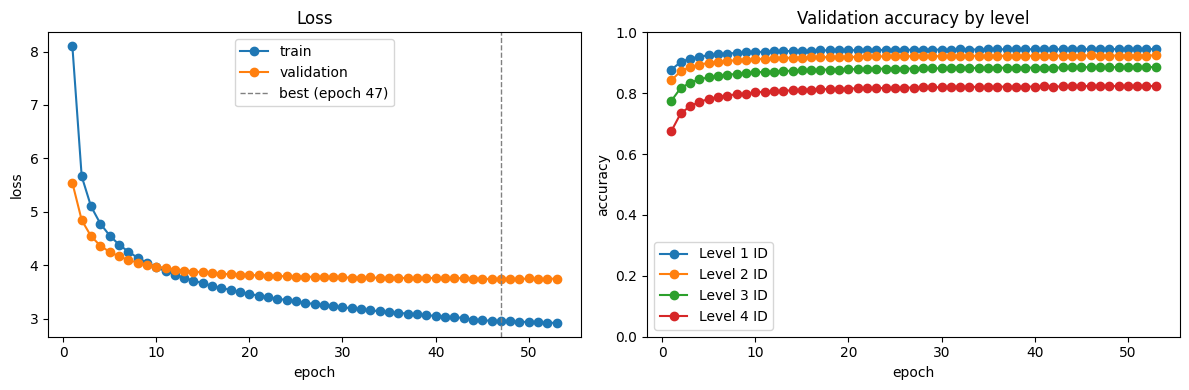

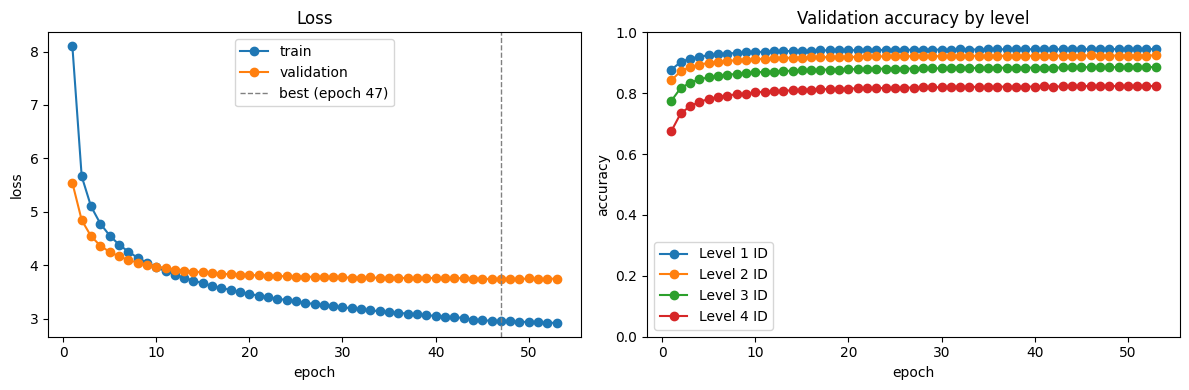

In [0]:
history = training.fit(model, train_loader, val_loader, cfg.nn, level_columns=levels)
plotting.plot_training_curves(history, levels)

### Checkpoint — save before evaluating

Written here, the moment training finishes, and before anything in the
sections below runs.

The reason is specific rather than general caution. Evaluating the
hierarchy builds dense `(n_rows x n_paths)` float32 arrays — several of
them live at once, once per joint mode — and on a large taxonomy that is
the most memory-hungry thing in the notebook. If it dies, the weights die
with it, and those took far longer to produce than anything they are
about to be measured with.

This bundle has no calibrators and no thresholds; they do not exist yet.
It is the model and everything needed to run it. Section 5 writes the
complete bundle to a separate directory once the rest has succeeded.

In [0]:
import joblib
from nn_classifier import artifacts


def _saved_cleaner():
    """The cleaner from notebook 01, or None rather than an exception.

    A checkpoint that refuses to write because an optional piece is
    missing would defeat its own purpose.
    """
    try:
        return joblib.load(paths.output_path("cleaner.joblib"))
    except (FileNotFoundError, OSError):
        print("[checkpoint] no cleaner.joblib found; saving without it")
        return None


CHECKPOINT_DIR = paths.output_dir() / f"{BUNDLE_NAME}_checkpoint"

artifacts.save_bundle(
    CHECKPOINT_DIR,
    model=model, model_kind="torch",
    hierarchy=H,
    cleaner=_saved_cleaner(),
    vectorizer=vec,
    config=cfg,
    history=history,
    n_training_rows=len(train_df),
    notes="Checkpoint written straight after training. "
          "No calibrators, no thresholds -- see nn_sparse_v1 for the full bundle.",
)

[artifacts] wrote 6 files to /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1_checkpoint


PosixPath('/Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1_checkpoint')

Read the gap between the two loss curves rather than either one.
Training loss below validation loss and still falling while validation
flattens is the model memorising part numbers — and the fix for that is
upstream, in `FilterConfig.min_token_count`, not in the optimiser.

In [0]:
# Logits, not probabilities: temperature scaling divides logits by a
# scalar before the softmax, so anything that softmaxed here would have
# thrown away exactly what the calibration step needs. The loader must
# not shuffle, or the targets will not line up.
val_logits, val_targets = training.collect_logits(model, val_loader)
val_logits_np = [lg.numpy() for lg in val_logits]
assert np.array_equal(val_targets.numpy(), y_val), "loader order drifted"

The three modes, on identical probabilities. Run them against each other
and read the rows: the per-level accuracies usually barely move while the
path accuracy does, which is the whole argument for constraining
predictions to paths that exist.

`joint_mode=None` is the honest answer to four separate questions, and
its levels are free to contradict each other. Do not ship that output to
anything expecting a real path.

**This comparison runs on a subsample.** Scoring builds a
`(rows x paths)` block, and doing it three times over a full validation
set is the most memory-hungry thing in this notebook — it is what
crashed it before. A few thousand rows separates three modes perfectly
well; the chosen mode is then evaluated on everything below.

In [0]:
probs = training.softmax_probs(val_logits)

# A subsample is enough to rank three modes, and cheap enough to be safe.
# Set COMPARE_ROWS = None to use the whole validation set.
COMPARE_ROWS = 5000

if COMPARE_ROWS and COMPARE_ROWS < len(val_df):
    rng = np.random.default_rng(cfg.nn.seed)
    pick = rng.choice(len(val_df), size=COMPARE_ROWS, replace=False)
    probs_cmp = [p[pick] for p in probs]
    truth_cmp = val_df.iloc[pick].reset_index(drop=True)
else:
    pick, probs_cmp, truth_cmp = None, probs, val_df
print(f"comparing modes on {len(truth_cmp):,} of {len(val_df):,} validation rows")

results = {}
for mode in ["independent", "conditional", None]:
    frame = hierarchy.predictions_frame(
        H, probs_cmp, mode=mode,
        normalise=cfg.hierarchy.normalise,
        predict_all_levels=True,
        batch_size=cfg.hierarchy.batch_size,
    )
    results[str(mode)] = evaluation.evaluate(frame, truth_cmp, levels, verbose=False)
    del frame

evaluation.compare_modes(results)

comparing modes on 5,000 of 81,185 validation rows


,run,path_accuracy,n_rows,Level 1 ID,Level 2 ID,Level 3 ID,Level 4 ID
0,independent,0.8208,5000,0.9500,0.9256,0.8886,0.8208
1,conditional,0.8188,5000,0.9482,0.9230,0.8856,0.8188
2,None,0.8030,5000,0.9462,0.9242,0.8884,0.8254


[hierarchy] 81,185 rows x 3,512 paths in 20 block(s) of 4,096 (58 MB each)
rows evaluated: 81,185
full-path accuracy: 0.8226
  Level 1 ID: 0.9500 over 23 classes
  Level 2 ID: 0.9276 over 154 classes
  Level 3 ID: 0.8880 over 716 classes
  Level 4 ID: 0.8226 over 3,512 classes
  Level 1 ID top-5: 0.9904
  Level 2 ID top-5: 0.9829
  Level 3 ID top-5: 0.9699
  Level 4 ID top-5: 0.9462


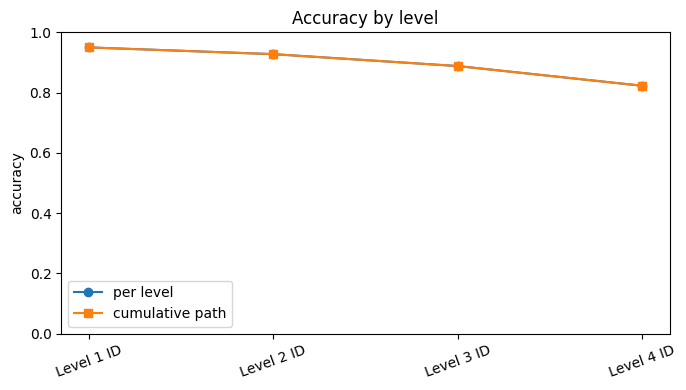

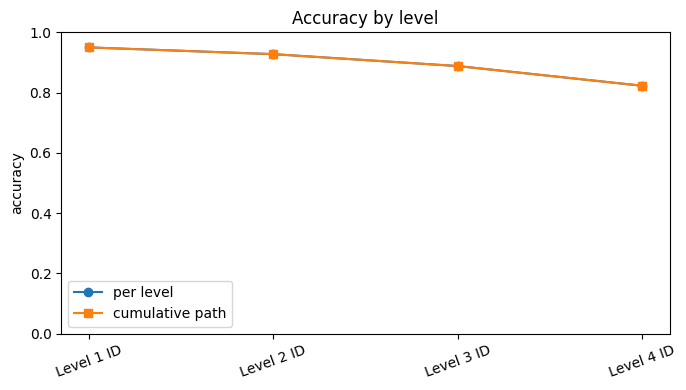

In [0]:
MODE = cfg.hierarchy.joint_mode
frame = hierarchy.predictions_frame(
    H, probs, mode=MODE, normalise=cfg.hierarchy.normalise,
    predict_all_levels=cfg.hierarchy.predict_all_levels,
    top_k=cfg.hierarchy.top_k, batch_size=cfg.hierarchy.batch_size,
    verbose=True)
result = evaluation.evaluate(frame, val_df, levels, level_probs=probs, level_targets=y_val)

plotting.plot_per_level_accuracy(result.per_level, result.prefix)

accuracy
0.9904169489437704
0.9828786105807723
0.9699451869187657
0.9462339102050872


bucket,count,share,accuracy
"[0.0, 0.1)",23,2.833035659296668E-4,0.0
"[0.1, 0.2)",245,0.00301779885446819,0.06938775510204082
"[0.2, 0.3)",807,0.009940259900227875,0.1771995043370508
"[0.3, 0.4)",1550,0.01909219683439059,0.24451612903225806
"[0.4, 0.5)",2393,0.029475888403030115,0.3543669034684496
"[0.5, 0.6)",3930,0.04840795713493872,0.44681933842239185
"[0.6, 0.7)",3533,0.043517891236065774,0.5191055759977357
"[0.7, 0.8)",4426,0.05451746012194371,0.6287844554902847
"[0.8, 0.9)",7087,0.08729445094537168,0.7266826583885988
"[0.9, 1.0)",57191,0.7044527930036337,0.9420363343882778


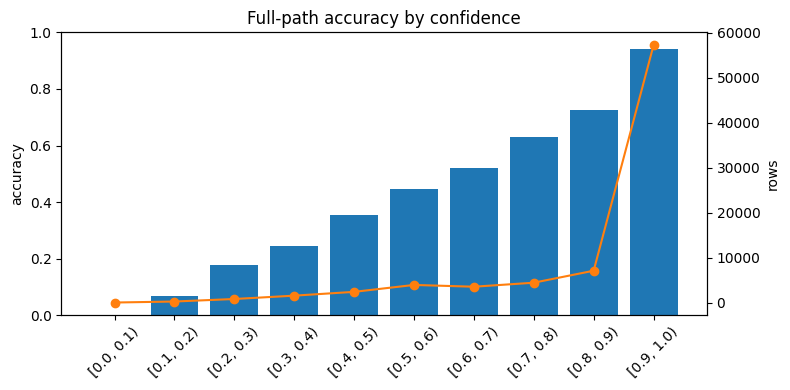

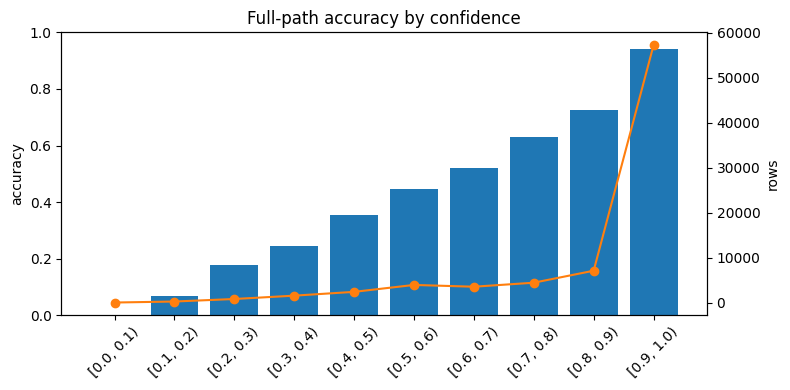

In [0]:
# Top-5 against top-1, and accuracy by confidence band. A large gap
# between the two means the model has the right neighbourhood and is
# losing on the final discrimination -- a different problem, with
# different fixes, than a model that is simply lost.
display(pd.Series(result.top_k).to_frame("accuracy"))
display(result.buckets)
plotting.plot_accuracy_by_bucket(result.buckets, "Full-path accuracy by confidence")

actual,predicted,count,share_of_errors
L4-12784899,L4-12784904,112,0.007778317938745746
L4-12783327,L4-12783320,64,0.004444753107854712
L4-12783320,L4-12783327,49,0.003403014098201264
L4-12798920,L4-13534728,48,0.003333564830891034
L4-12784904,L4-12784903,48,0.003333564830891034
L4-13534724,L4-13534728,46,0.003194666296270574
L4-12784863,L4-12784855,45,0.0031252170289603446
L4-12783317,L4-12783320,44,0.0030557677616501145
L4-12810741,L4-12810735,42,0.002916869227029655
L4-12785688,L4-12785684,41,0.002847419959719425


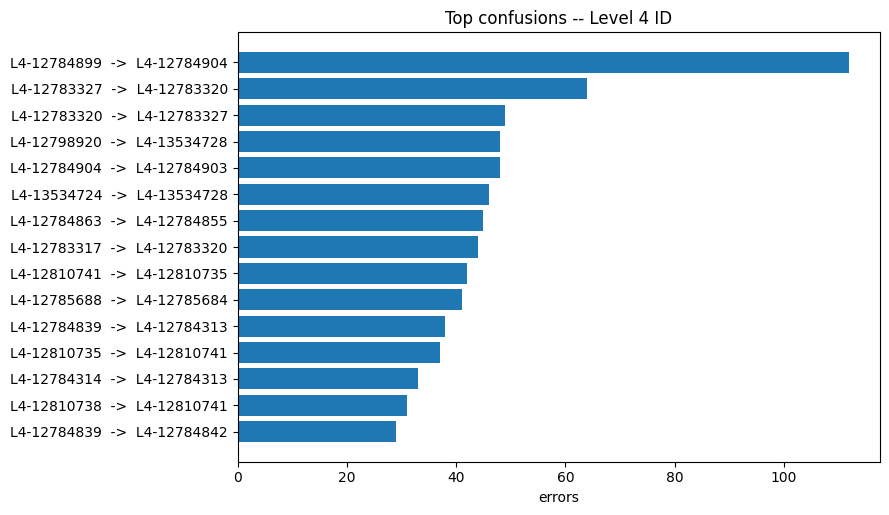

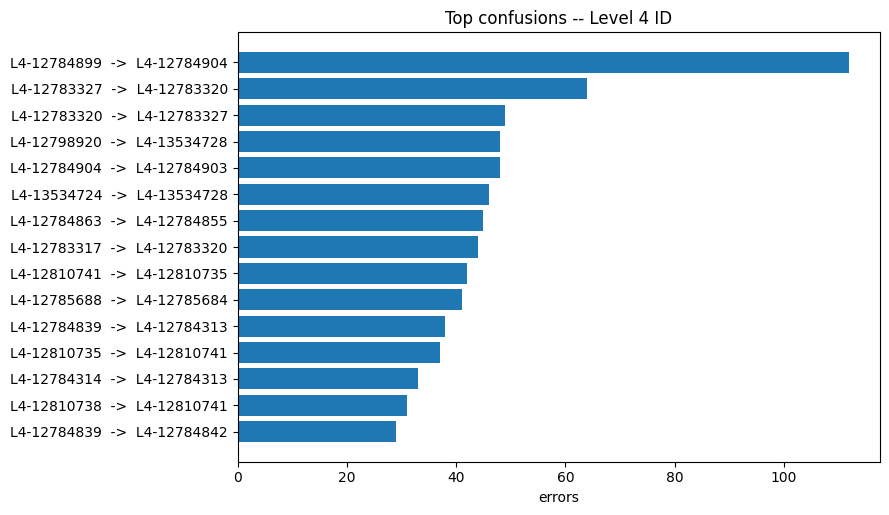

In [0]:
# Usually the most actionable output in the notebook. A confusion that
# dominates this list is normally a taxonomy problem -- two categories no
# description could distinguish -- rather than a model problem, and no
# amount of tuning will fix it.
confusions = evaluation.top_confusions(frame, val_df, levels[-1], n=20)
display(confusions)
plotting.plot_top_confusions(confusions, title=f"Top confusions -- {levels[-1]}")

## Calibration — section D

Two steps, answering different questions.

**Fit a temperature.** A single scalar dividing the logits before the
softmax. It cannot change which class wins, so accuracy is untouched and
only the confidence moves. Fitted against plain cross-entropy, not the
smoothed loss used in training — smoothing is a regulariser, and
calibrating against it would calibrate toward the smoothed target rather
than toward being right. One temperature per level, because level 1 has a
dozen classes and is nearly always right while level 4 has thousands and
is not; a single scalar that fixes one will break the other.

**Then validate it.** The reliability diagram, the ECE, and the
coverage/accuracy table. This half is not optional: a calibrator fitted
and never checked is a worse position than no calibrator, because the
number now looks trustworthy.

The whole point is that on unlabelled data you cannot measure accuracy.
So you characterise the confidence → correctness relationship here, on
validation, and reuse the threshold you choose on rows you will never be
able to check.

In [0]:
from nn_classifier.calibration import LevelCalibrators

calibrators = LevelCalibrators(method=cfg.calibration.method, level_columns=levels)
calibrators.fit(val_logits_np, y_val, max_iter=cfg.calibration.max_iter)

probs_raw = training.softmax_probs(val_logits)
probs_cal = calibrators.transform(val_logits_np)

reports_raw = calibration.validate_all_levels(probs_raw, y_val, levels, cfg.calibration,
                                              verbose=False)
reports_cal = calibration.validate_all_levels(probs_cal, y_val, levels, cfg.calibration)

pd.DataFrame([
    {"level": name,
     "accuracy": reports_cal[name].accuracy,
     "ECE raw": reports_raw[name].ece,
     "ECE calibrated": reports_cal[name].ece,
     "threshold @ %.0f%%" % (100 * cfg.calibration.target_accuracy):
         reports_cal[name].chosen_threshold}
    for name in levels
])

[calib] Level 1 ID: [calib] temperature = 0.8146 (model was under-confident)
[calib] Level 2 ID: [calib] temperature = 0.8539 (model was under-confident)
[calib] Level 3 ID: [calib] temperature = 0.8823 (model was under-confident)
[calib] Level 4 ID: [calib] temperature = 0.9112 (model was under-confident)
[calib] Level 1 ID: accuracy=0.944  ECE=0.0034  threshold=0.42  (n=81,185)
[calib] Level 2 ID: accuracy=0.923  ECE=0.0095  threshold=0.58  (n=81,185)
[calib] Level 3 ID: accuracy=0.886  ECE=0.0170  threshold=0.74  (n=81,185)
[calib] Level 4 ID: accuracy=0.824  ECE=0.0221  threshold=0.83  (n=81,185)


,level,accuracy,ECE raw,ECE calibrated,threshold @ 95%
0,Level 1 ID,0.944460,0.038174,0.003379,0.42
1,Level 2 ID,0.922991,0.034614,0.009535,0.58
2,Level 3 ID,0.885730,0.030193,0.016987,0.74
3,Level 4 ID,0.824155,0.022284,0.022083,0.83


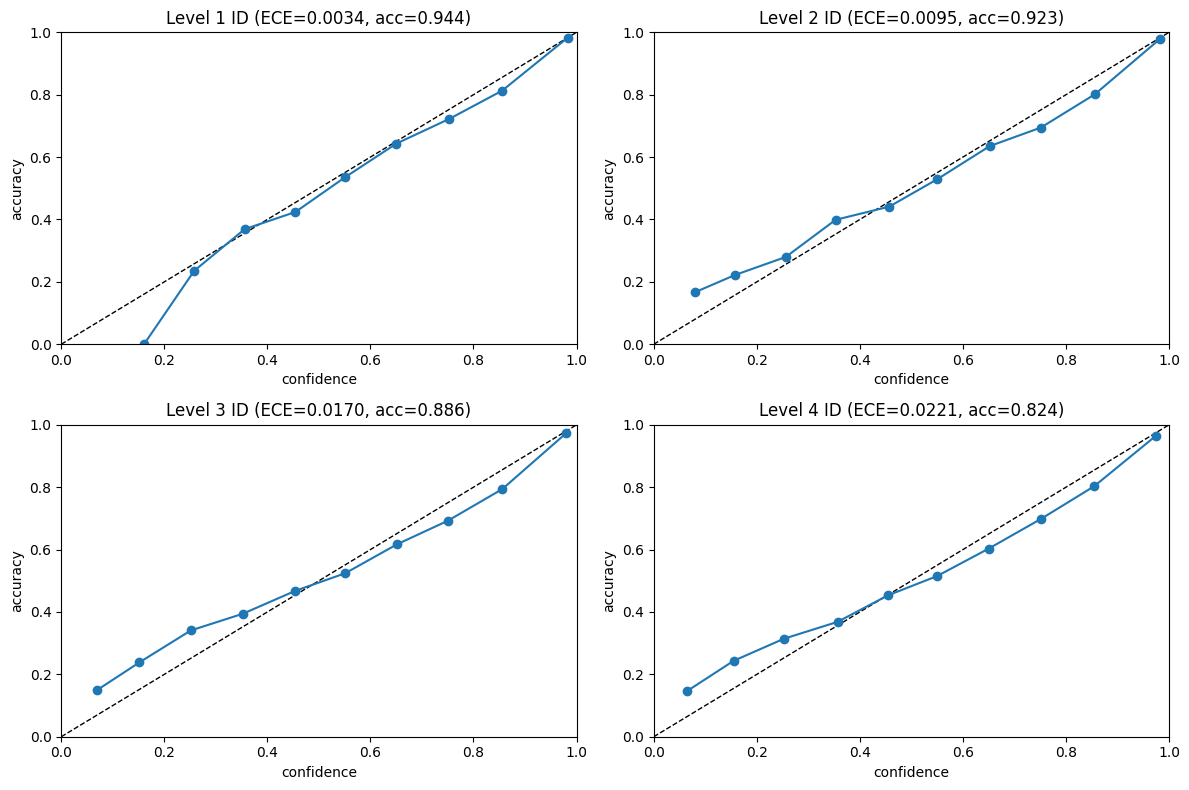

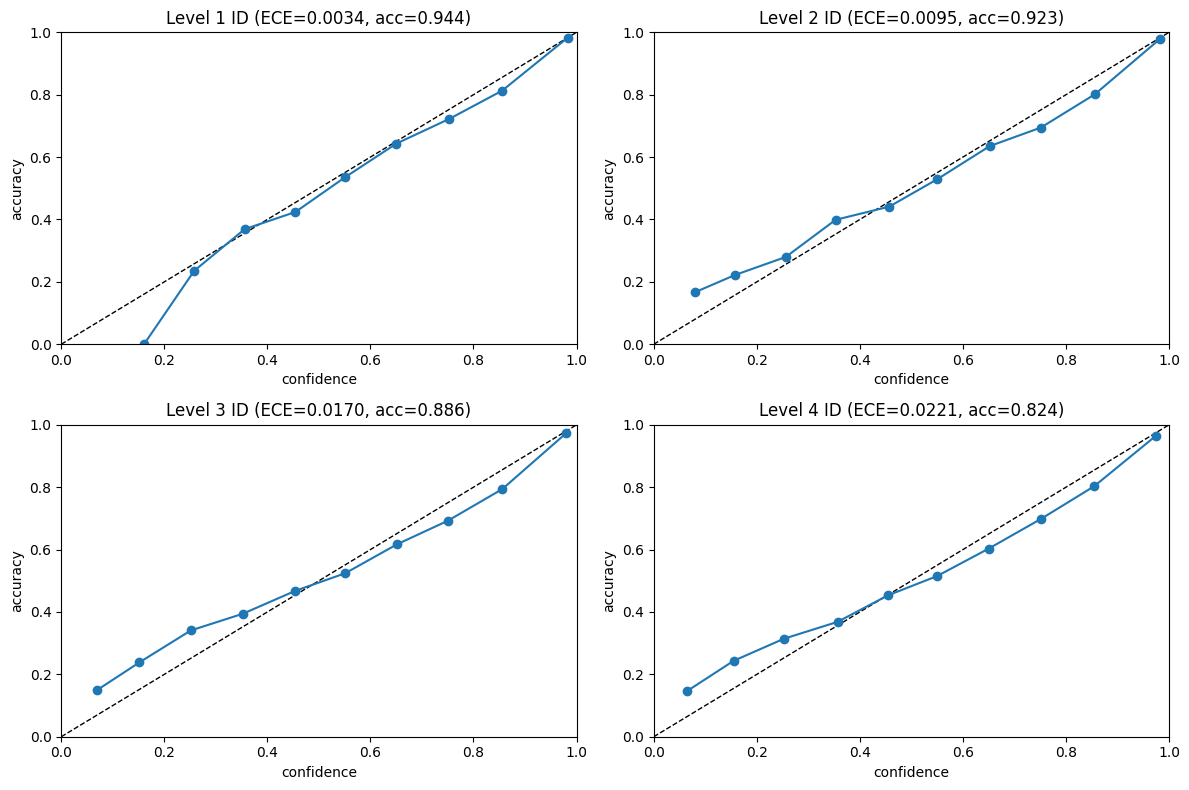

In [0]:
plotting.plot_reliability_grid(reports_cal)

bin,count,mean_confidence,accuracy,gap
"[0.0, 0.1)",684,0.0644463107292132,0.14619883040935672,-0.08175251968014352
"[0.1, 0.2)",1175,0.15504491648141375,0.24340425531914894,-0.0883593388377352
"[0.2, 0.3)",1643,0.25237798821396457,0.3140596469872185,-0.06168165877325393
"[0.3, 0.4)",2327,0.356755960471752,0.3682853459389772,-0.011529385467225206
"[0.4, 0.5)",3211,0.4547245565120842,0.4534412955465587,0.0012832609655255012
"[0.5, 0.6)",3956,0.5493183556804763,0.5146612740141557,0.03465708166632053
"[0.6, 0.7)",4349,0.6500433727252563,0.6031271556679696,0.04691621705728666
"[0.7, 0.8)",4931,0.7517947424524238,0.6986412492395052,0.05315349321291862
"[0.8, 0.9)",7741,0.8545789102253842,0.8028678465314559,0.051711063693928305
"[0.9, 1.0)",51168,0.9746759010733963,0.9649585678549093,0.009717333218487001


threshold,coverage,n_auto,accuracy_at_threshold,n_reviewed,errors_auto
0.3,0.9568639527006221,77683,0.8496968746185303,3502,11676
0.4,0.9282010223563466,75356,0.8645628690719604,5829,10206
0.5,0.8886493810432962,72145,0.8828608989715576,9040,8451
0.6,0.8399211677033935,68189,0.9042220711708069,12996,6531
0.7,0.786352158649997,63840,0.9247336983680725,17345,4805
0.8,0.7256143376239453,58909,0.9436588883399963,22276,3319
0.9,0.6302642113690953,51168,0.9649585485458374,30017,1793


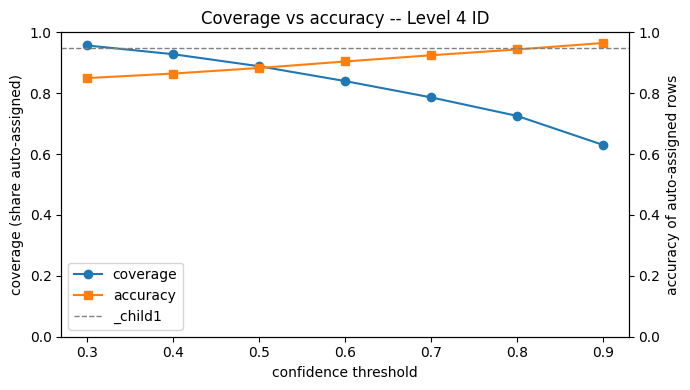

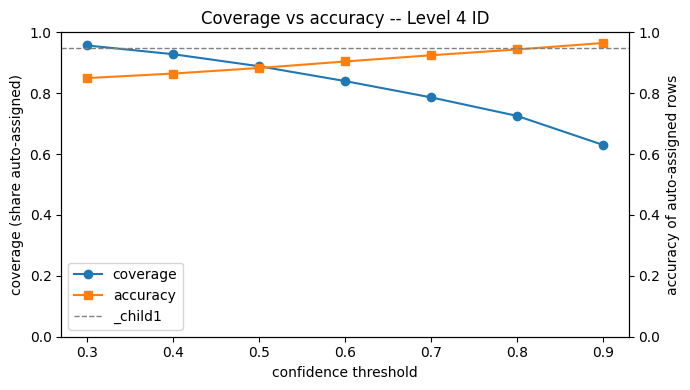

In [0]:
deep = reports_cal[levels[-1]]
display(deep.reliability)
display(deep.coverage)
plotting.plot_coverage_curve(deep, target_accuracy=cfg.calibration.target_accuracy)

The coverage table is where the threshold decision actually gets made.
Coverage is the share of rows auto-assigned, accuracy is how often those
are right, and `n_reviewed` is the workload the rest represents.
Choosing a threshold is choosing a row here.

In [0]:
# Variable-depth assignment. When the model cannot pick a level-4 category
# confidently enough it can still assign level 2 correctly, and a correct
# level 2 is worth more than a coin-flip level 4. A depth whose target is
# unreachable gets inf, so the cascade falls straight through it.
frame_cal = hierarchy.predictions_frame(
    H, probs_cal, mode=MODE, normalise=cfg.hierarchy.normalise, predict_all_levels=True,
    batch_size=cfg.hierarchy.batch_size)

joint_report = calibration.validate_joint(frame_cal, val_df, levels, cfg.calibration)
thresholds = calibration.prefix_thresholds(
    frame_cal, val_df, levels, target_accuracy=cfg.calibration.target_accuracy)

cascaded = calibration.apply_cascade(frame_cal, levels, thresholds)
from nn_classifier.predict import score_summary
score_summary(cascaded, levels)

[calib] joint path: accuracy=0.823  ECE=0.0765  threshold=0.95  (n=81,185)
[calib] depth 1 (Level 1 ID): threshold=0.37  base accuracy=0.950
[calib] depth 2 (Level 2 ID): threshold=0.95  base accuracy=0.928
[calib] depth 3 (Level 3 ID): threshold=0.99  base accuracy=0.888
[calib] depth 4 (Level 4 ID): threshold=0.95  base accuracy=0.823


,assigned_depth,level,rows,share,mean_confidence
0,0,no assignment,4,0.000049,0.145497
1,1,Level 1 ID,3716,0.045772,0.610847
2,2,Level 2 ID,7302,0.089943,0.678805
3,3,Level 3 ID,16391,0.201897,0.763236
4,4,Level 4 ID,53772,0.662339,0.990326


### The same cascade, driven by the per-level probabilities

The block above thresholds the **joint** prefix mass, and on this model
that is the wrong signal. `independent` mode multiplies four
probabilities and renormalises over 3,473 paths, which is close to
winner-take-all: the joint ECE came out around 0.105 against 0.013-0.017
for the per-level numbers it was built from, prefix mass saturates near
1.0 at every depth, and depths 1-3 report `unreachable` even though
level 1 on its own reaches 95% accuracy at a threshold of 0.65.

Below, the same cascade driven by each level's calibrated probability
for **the class actually predicted** — not that level's argmax, since
under a joint mode the path may not agree with it.

This is exactly right rather than merely convenient, for one reason: in
a tree, a node at depth d determines its whole ancestry, so "the prefix
through depth d is correct" and "the level-d prediction is correct" are
the same statement. A per-level threshold *is* a prefix threshold here.
It would not be for a DAG.

In [0]:
# Codes for what the joint mode actually predicted, per level.
pred_codes = H.encode(
    frame_cal[[f"Predicted {c}" for c in levels]]
        .rename(columns={f"Predicted {c}": c for c in levels})
)

# Each level's calibrated probability for that predicted class.
level_conf = calibration.level_confidence(probs_cal, pred_codes)

thresholds_pl = calibration.per_level_cascade_thresholds(
    level_conf, pred_codes, y_val, levels,
    target_accuracy=cfg.calibration.target_accuracy,
)

cascaded_pl = calibration.apply_cascade_per_level(
    frame_cal, level_conf, levels, thresholds_pl)
report_pl = calibration.cascade_report(cascaded_pl, pred_codes, y_val, levels)
display(report_pl)
print(f"coverage: {report_pl.attrs['coverage']:.1%}")

[calib] depth 1 (Level 1 ID): threshold=0.05  base accuracy=0.950  coverage at threshold=0.999
[calib] depth 2 (Level 2 ID): threshold=0.55  base accuracy=0.928  coverage at threshold=0.950
[calib] depth 3 (Level 3 ID): threshold=0.74  base accuracy=0.888  coverage at threshold=0.855
[calib] depth 4 (Level 4 ID): threshold=0.83  base accuracy=0.823  coverage at threshold=0.702


assigned_depth,level,rows,share,accuracy
0,no assignment,27,3.325737513087393E-4,null
1,Level 1 ID,3472,0.04276652090903492,0.5973502304147466
2,Level 2 ID,7480,0.09213524665886555,0.7755347593582887
3,Level 3 ID,13182,0.1623698959167334,0.8582916097708997
4,Level 4 ID,57024,0.7023957627640574,0.9502139450056116


coverage: 100.0%


In [0]:
# Side by side. Coverage is the share auto-assigned at any depth; the
# accuracy column is what the threshold was chosen to guarantee,
# measured after the fact.
joint_cov = float((cascaded["Assigned Depth"] > 0).mean())
pl_cov = report_pl.attrs["coverage"]

print(f"joint prefix mass : {joint_cov:6.1%} coverage")
print(f"per-level         : {pl_cov:6.1%} coverage")
print(f"                    {pl_cov - joint_cov:+6.1%}")
print()
print("thresholds")
for d, name in enumerate(levels, start=1):
    j = thresholds.get(d, float("inf"))
    p = thresholds_pl.get(d, float("inf"))
    fmt = lambda v: "unreachable" if not np.isfinite(v) else f"{v:.2f}"
    print(f"  depth {d} ({name}): joint={fmt(j):>11}   per-level={fmt(p):>11}")

joint prefix mass : 100.0% coverage
per-level         : 100.0% coverage
                     -0.0%

thresholds
  depth 1 (Level 1 ID): joint=       0.37   per-level=       0.05
  depth 2 (Level 2 ID): joint=       0.95   per-level=       0.55
  depth 3 (Level 3 ID): joint=       0.99   per-level=       0.74
  depth 4 (Level 4 ID): joint=       0.95   per-level=       0.83


## 5 · Save

In [0]:
import joblib
from nn_classifier import artifacts

bundle_dir = paths.output_dir() / BUNDLE_NAME
artifacts.save_bundle(
    bundle_dir,
    model=model, model_kind="torch",
    hierarchy=H,
    cleaner=joblib.load(paths.output_path("cleaner.joblib")),
    vectorizer=vec,
    calibrators=calibrators,
    # Both sets. The joint prefix thresholds saturate on this
    # taxonomy -- depth 3 comes back unreachable -- so the per-level
    # set is the operative one and predict.score() prefers it.
    thresholds=thresholds,
    per_level_thresholds=thresholds_pl,
    # 11a's copy, not the shared one -- see the note there.
    hierarchy_lookup=pd.read_csv(
        paths.data_path("hierarchy_lookup_codes.csv"), dtype="str"),
    config=cfg, history=history,
    metrics={
        "path_accuracy": result.path_accuracy,
        "joint_ece": joint_report.ece,
        "default_threshold": cfg.calibration.default_threshold,
        **{f"{name} accuracy": r.accuracy for name, r in reports_cal.items()},
    },
    n_training_rows=len(train_df),
    notes=f"Arm {ARM} ({ARM_LABEL}). Vendor + Prodcat + UNSPSC + Prodline markers.",
)
print(artifacts.describe_bundle(bundle_dir))

[artifacts] wrote 8 files to /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1
bundle:        /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1
created:       2026-09-29T02:12:34+00:00
model:         MultiHeadSparseInputMLP (torch)
levels:        ['Level 1 ID', 'Level 2 ID', 'Level 3 ID', 'Level 4 ID']
classes:       [23, 154, 716, 3512]
valid paths:   3,512
training rows: 546333
thresholds:    {'1': 0.37, '2': 0.95, '3': 0.99, '4': 0.95}  (joint prefix)
per-level:     {'1': 0.05, '2': 0.55, '3': 0.74, '4': 0.83}  <- operative
notes:         Arm bl1 (blacklist #1). Vendor + Prodcat + UNSPSC + Prodline markers.
  path_accuracy: 0.8226396441459656
  joint_ece: 0.07646891802848538
  default_threshold: 0.6
  Level 1 ID accuracy: 0.9444602131843567
  Level 2 ID accuracy: 0.9229906797409058
  Level 3 ID accuracy: 0.8857301473617554
  Level 4 ID accuracy: 0.82415

In [0]:
import json

# A stamp 06 can check. The bundle name already encodes the arm, but
# a name is easy to mistype into the wrong notebook; this records what
# actually produced the weights.
stamp = {
    "arm": ARM,
    "label": ARM_LABEL,
    "blacklist_file": BLACKLIST_FILE,
    "blacklist_scope": BLACKLIST_SCOPE if BLACKLIST_FILE else None,
    "blacklist_ids": len(BLACKLIST),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "features": int(X_train.shape[1]),
    "full_path_accuracy": float(result.path_accuracy),
}
_p = bundle_dir / "arm.json"
_p.write_text(json.dumps(stamp, indent=1), encoding="utf-8")
print(json.dumps(stamp, indent=1))
print(f"\nwrote {_p}")

{
 "arm": "bl1",
 "label": "blacklist #1",
 "blacklist_file": "blacklist_1.txt",
 "blacklist_scope": "train",
 "blacklist_ids": 204992,
 "train_rows": 546333,
 "val_rows": 81185,
 "features": 144437,
 "full_path_accuracy": 0.8226396441459656
}

wrote /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1/arm.json
